In [1]:
!pip install --upgrade openpyxl

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

#Catalogos

## Tiendas

Dado que el catalogo de tiendas se encuentra fragmentado, es necesario unificarlo.

In [9]:
cagsa= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda CAGSA.xlsx", engine="openpyxl")

vargas= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Casa Vargas.xlsx", engine="openpyxl")

coma= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Coma.xlsx", engine="openpyxl")

decasa= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Decasa.xlsx", engine="openpyxl")

duero= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Duero.xlsx", engine="openpyxl")

garis= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Garis.xlsx", engine="openpyxl")

rivera= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Gran Bodega.xlsx", engine="openpyxl")

soledad= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda La Soledad.xlsx", engine="openpyxl")

masbodega= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Mas Bodega.xlsx", engine="openpyxl")

miniabastos= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Mini Abastos.xlsx", engine="openpyxl")

z= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda PCZ.xlsx", engine="openpyxl")

promotora= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Promotora del Norte.xlsx", engine="openpyxl")

propasa= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Propasa.xlsx", engine="openpyxl")

sahuayo= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Sahuayo.xlsx", engine="openpyxl")

sanchez= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Sanchez.xlsx", engine="openpyxl")

lugo= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Santos Lugo.xlsx", engine="openpyxl")

super= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Su Super.xlsx", engine="openpyxl")

aki= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Super Aki.xlsx", engine="openpyxl")

toscano= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Vigil Toscano.xlsx", engine="openpyxl")

zorro= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Zorro Abarrotero.xlsx", engine="openpyxl")

parral= pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Tda Parral.xlsx", engine="openpyxl")


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:

In [10]:
tdas=pd.concat([cagsa,vargas,coma,decasa,duero,garis,rivera,soledad,miniabastos,parral,
                z,promotora,propasa,sahuayo,sanchez,lugo,super,aki,toscano,zorro,masbodega])

tdas = tdas.replace(r'\s+', ' ', regex=True)

tdas=tdas.iloc[:,[0,1,2]]

/tmp/ipython-input-3825371896.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tdas=pd.concat([cagsa,vargas,coma,decasa,duero,garis,rivera,soledad,miniabastos,parral,


In [11]:
tdas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1672 entries, 0 to 78
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Holding                       1672 non-null   object
 1   Código Punto de Venta Cadena  1672 non-null   object
 2   Nombre de Tienda              1672 non-null   object
dtypes: object(3)
memory usage: 52.2+ KB


In [12]:
tdas['Holding '].unique()

array(['CAGSA', 'Casa Vargas', 'COMA', 'DECASA', 'Duero', 'Garis',
       'Gran Bodega', 'La Soledad', 'Mini Abastos', 'Abastecedora Parral',
       'PCZ', 'Promotora Abarrotera del Norte', 'PROPASA', 'Sahuayo',
       'Grupo Sanchez', 'Casa Santos Lugo', 'Su Super', 'Super Aki',
       'Vigil Toscano', 'Zorro', 'Más Bodega'], dtype=object)

In [13]:
#tdas.to_excel('tdas.xlsx',sheet_name = 'Sheet1',index=False)

Dado que pueden existir identificadores que tengan repetición con otra cadena, se recurre a realizar una Key general: Cadena + Codigo

In [14]:
tdas['key_tda'] =tdas['Holding '].astype(str) + tdas['Código Punto de Venta Cadena'].astype(str)

tdas=tdas.iloc[:,[3]]

tdas.tail(5)

,key_tda
74,Más Bodega68
75,Más Bodega31
76,Más Bodega27
77,Más Bodega168
78,Más Bodega169


## Catalogo-BI

catalogo de productos general (construido con historicos). Solo para cuando me entreguen la información sin relacionar los codigos de material con los codigos del cliente

In [15]:
ab=pd.read_excel("/content/drive/Shareddrives/Catalogos_SO/Catalogo_Productos.xlsx",
                 sheet_name="Catalogo",
                 engine="openpyxl")
ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3051 entries, 0 to 3050
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Agrupador (C+V)         3051 non-null   object 
 1   Satus SKU               2912 non-null   object 
 2   >ATTP5                  3051 non-null   object 
 3   Madre o hijo            434 non-null    object 
 4   Largo                   3051 non-null   int64  
 5   Inicio (2)              3051 non-null   object 
 6   Variante (2)            1928 non-null   object 
 7   Constante(6)            1929 non-null   object 
 8   >Código Material*       3051 non-null   object 
 9   >Desc. Código Material  3051 non-null   object 
 10  >Marca                  2982 non-null   object 
 11  SUBMARCA                2982 non-null   object 
 12  Desc_Mayoreo            3051 non-null   object 
 13  >ATTP4                  2982 non-null   object 
 14  >Desc. Sector Material  2982 non-null   

In [16]:
# seleccion de columnas por index
#ab=ab.iloc[:,[1,2,3,5]]

# selccionar columnas por index
ab= ab.iloc[:,[8]]

# renombrar las columnas
#ab= ab.rename(columns={'identificador': "CLAVE"})
ab= ab.rename(columns={'>Código Material*': "AB actual"})

In [17]:
ab.head()

,AB actual
0,AB11000855
1,AB10335148
2,AB10331522
3,AB10335179
4,AB10335315


## Prod-Holding

catalogo de productos general (construido con historicos). Solo para cuando me entreguen la información sin relacionar los codigos de material con los codigos del cliente

In [19]:
prod_holding=pd.read_excel("/content/drive/MyDrive/Sell Out/Dbyte_SO/Prod_Holding.xlsx",
                 engine="openpyxl")

prod_holding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   key              3259 non-null   object
 1   Site             2482 non-null   object
 2   Holding          3259 non-null   object
 3   identificador    3146 non-null   object
 4   descripcion      3259 non-null   object
 5   CODIGO           3115 non-null   object
 6   codigo_anterior  53 non-null     object
 7   EAN              758 non-null    object
 8   Factor_Caja      2279 non-null   object
 9   Peso_x_caja      2322 non-null   object
dtypes: object(10)
memory usage: 254.7+ KB


In [20]:
# seleccion de columnas por index
prod_holding=prod_holding.iloc[:,[5,7]]

# reordenar columnas por index
prod_holding= prod_holding.iloc[:,[1,0]]

prod_holding['CODIGO']= prod_holding['CODIGO'].drop_duplicates()

# renombrar las columnas
#ab= ab.rename(columns={'identificador': "CLAVE"})
#ab= ab.rename(columns={'>Código Material*': "AB actual"})

prod_holding.head(5)

,EAN,CODIGO
0,NaN,AB16000852
1,NaN,AB16335636
2,NaN,eliminar
3,NaN,AB12335678
4,NaN,AB11338699


## Dbyte-Materiales

1) Materiales Dbyte

In [22]:
# Materiales Dbyte
mat_dbyte=pd.read_excel('/content/drive/MyDrive/Sell Out/Dbyte_SO/Catalogo_Productos_SoftysSO.xlsx')

mat_dbyte=mat_dbyte.replace(r'\s+', ' ', regex=True)

mat_dbyte.head(5)

,Corporativo,Familia,Categoria,Marca,Sub_marca,Variedad_o_sabor,Empaque,Tipo,Status,Presentacion,...,Descripcion_No_Homologada_SKU,ID_UPC,Descripcion_Administracion,Numer_Categoria_SR,Categoria_SR,Prime_Item_Desc,Consumer_ID,Prime_Item_Nbr,Item_Soriana,Negocio
0,Ontex,Adultcare,Heavy Inco,Affective,Active,M MABESA,Adulto,Active,CONVENCIONAL,Grande,...,Panal Para Adulto AFFECTIVE Active Grande Paq 18u,137215,Adult Pants Affective Grande CA 4/18,-,-,-,-,-,-,Cuidado Adulto
1,Ontex,Adultcare,Heavy Inco,Affective,Active,M MABESA,Adulto,Active,CONVENCIONAL,Mediano,...,Panal Para Adulto AFFECTIVE Active Median Paq 20u,137530,Adult Pants Affective Mediano CA 4/20,-,-,-,-,-,-,Cuidado Adulto
2,Ontex,Adultcare,Heavy Inco,Affective,Active,M MABESA,Adulto,Active,CONVENCIONAL,T2,...,PANAL AD SAFE PANT S,43170,Adult Pants Affective Active Chica 6/12,-,-,AFFEC ACTIVE CH,190988639,100425325,-,Cuidado Adulto
3,Ontex,Adultcare,Heavy Inco,Affective,Active,M MABESA,Adulto,Active,CONVENCIONAL,T2,...,PANAL AD SAFE PANT S,42675,Affective Active Ropa Interior Desechable para...,-,-,AFFEC ACTIVE CH,190988639,100425325,-,Cuidado Adulto
4,Ontex,Adultcare,Heavy Inco,Affective,Active,M MABESA,Adulto,Active,CONVENCIONAL,T2,...,PANAL AD SAFE PANT S,43420,Affective Active Ropa Interior Desechable para...,-,-,-,-,-,-,Cuidado Adulto


In [23]:
import re

mat_dbyte=mat_dbyte.iloc[:,[12,13,17,18]]
#mat_dbyte.columns.values[0] = "desc_dbyte"
#mat_dbyte.columns.values[1] = "sku_dbyte"
#mat_dbyte.columns.values[2] = "ipc_dbyte"
#mat_dbyte.columns.values[3] = "grupo_dbyte"


mat_dbyte['UPC'] = mat_dbyte['UPC'].astype(str)
mat_dbyte['UPC'] = [re.sub("^0+", "", ele) for ele in mat_dbyte['UPC']]

mat_dbyte['IPC'] = mat_dbyte['UPC'].astype(str)
mat_dbyte['IPC'] = [re.sub("^0+", "", ele) for ele in mat_dbyte['UPC']]

mat_dbyte=mat_dbyte.drop_duplicates(subset=["IPC"])

Separa el dataset y crear un indentificador

In [24]:
# Tabla del UPC dbyte
mat_dbyte_UPC=mat_dbyte[["UPC","Paquetes", "Factor_cajas"]]

mat_dbyte_UPC["KEY_UPC_dbyte"] = mat_dbyte_UPC["UPC"].astype(str) +  mat_dbyte_UPC["Factor_cajas"].astype(str) + mat_dbyte_UPC["Paquetes"].astype(str)

mat_dbyte_UPC=mat_dbyte_UPC.drop_duplicates(subset=["KEY_UPC_dbyte"])

# Tabla del IPC dbyte
mat_dbyte_IPC=mat_dbyte[["IPC","Paquetes", "Factor_cajas"]]

mat_dbyte_IPC["KEY_IPC_dbyte"] = mat_dbyte_IPC["IPC"].astype(str) +  mat_dbyte_IPC["Factor_cajas"].astype(str) + mat_dbyte_IPC["Paquetes"].astype(str)

mat_dbyte_IPC=mat_dbyte_IPC.drop_duplicates(subset=["KEY_IPC_dbyte"])


# unir vertical
#mat_dbyte=pd.concat([mat_dbyte_IPC,mat_dbyte_UPC],axis=0)

# Array de 2
UPC=mat_dbyte_UPC.iloc[:,[0,3]]
IPC=mat_dbyte_IPC.iloc[:,[0,3]]


## Puebla-Materiales

In [26]:
mat_softys=pd.read_excel('/content/drive/Shareddrives/Catalogos_SO/Catalogo_Puebla.xlsx')
mat_softys=mat_softys.replace(r'\s+', ' ', regex=True)

mat_softys.head(5)

,Item1,Description,Division_Dsc,2_Marca_Dsc,1_Tipo_Dsc,4_Talla_Dsc,3_Acabado_Dsc,Bolsas_X_Caja,Piezas_X_Bolsa,Conteo1,...,Subcategoria,Boton_Negocio_002,Dm_Prod_Division_Producto_Desc,Dm_Prod_Segmento_Mercado_Desc,Dm_Prod_Segmento_Mercado,Dm_Prod_Categoria,Dm_Prod_Division_Producto,Avta_Sector_Desc,Dm_Prod_Subcategoria,Dm_Prod_Subcategoria_Desc
0,IF25650943,BABYLOVE GUTE-NACHT YPP LRG/XLRG 4/09'S,España,Baby Love Gute-Nacht,Calzon Entrenador,T5,Top,4.0,9.0,04/09,...,Pants infantil,PERSONAL CARE,Cuidado infantil,SIN SEGMENTO,ST6,CBB,5602.0,MASIVOS,SBG,Pants Infantil - Especializado
1,JE25651240,KIDGETS YPP LRG/XLRG 4/12'S,Exportaciones VB,KIDGETS,Calzon Entrenador,T5,Top,4.0,12.0,04/12,...,Pants infantil,PERSONAL CARE,Cuidado infantil,SIN SEGMENTO,ST6,CBB,5602.0,MASIVOS,SBG,Pants Infantil - Especializado
2,FS25142341,OUR FAMILY TPP THIN S/4 4/23'S,Exportaciones VB,Our Family,Calzon Entrenador,T4,Top,4.0,23.0,04/23,...,Pants infantil,PERSONAL CARE,Cuidado infantil,SIN SEGMENTO,ST6,CBB,5602.0,MASIVOS,SBG,Pants Infantil - Especializado
3,IA25222540,SHOPKO TPP THIN NINO S/3 4/25'S,Exportaciones VB,SHOPKO,Calzon Entrenador,T3,Unico,4.0,25.0,04/25,...,Pants infantil,PERSONAL CARE,Cuidado infantil,SIN SEGMENTO,ST6,CBB,5602.0,MASIVOS,SBG,Pants Infantil - Especializado
4,5323331260,BABY PANTS C.E T2 6/12 NINA SUPERBABY,Nacional,Baby Pants,Calzon Entrenador,T2,Unico,6.0,12.0,06/12,...,Pants infantil,PERSONAL CARE,Cuidado infantil,MEDIO,ST4,CBB,5602.0,MASIVOS,SBG,Pants Infantil - Especializado


In [27]:
import re
mat_softys.Codigo_Barras_Bolsa = mat_softys.Codigo_Barras_Bolsa.astype(str)
mat_softys.Codigo_Barras_Caja = mat_softys.Codigo_Barras_Caja.astype(str)

mat_softys.Codigo_Barras_Bolsa = [re.sub("^0+", "", ele) for ele in mat_softys.Codigo_Barras_Bolsa]
mat_softys.Codigo_Barras_Caja = [re.sub("^0+", "", ele) for ele in mat_softys.Codigo_Barras_Caja]


#mat_softys=mat_softys.iloc[:,[0,1,7,8,12,13]]

#mat_softys.columns.values[0] = "item_softys"

mat_softys = mat_softys.drop_duplicates(subset="Codigo_Barras_Caja", inplace=False)
mat_softys = mat_softys.drop_duplicates(subset="Codigo_Barras_Bolsa", inplace=False)

In [28]:
# condicion a cumplir
condition = (mat_softys['Bolsas_X_Caja'] == "Material") | \
            (mat_softys['Piezas_X_Bolsa'] == "Material") | \
            (mat_softys['Bolsas_X_Caja'] == 0) | \
            (mat_softys['Piezas_X_Bolsa'] == 0)

# Delete rows based on the condition
mat_softys = mat_softys[~condition]

Separar el dataset y convertir el codigo de barras en un solo atributo

In [29]:
# bolsa

mat_softys_bolsa=mat_softys[["Item1","Description","Bolsas_X_Caja", "Piezas_X_Bolsa", "Codigo_Barras_Bolsa"]]

mat_softys_bolsa["KEY_UPC_softys"] = mat_softys_bolsa["Codigo_Barras_Bolsa"].astype(str) + mat_softys_bolsa["Piezas_X_Bolsa"].astype(str) + mat_softys_bolsa["Bolsas_X_Caja"].astype(str)

mat_softys_bolsa=mat_softys_bolsa.drop_duplicates(subset=["KEY_UPC_softys"])

mat_softys_bolsa=mat_softys_bolsa.iloc[:,[0,5]]

# caja

mat_softys_caja=mat_softys[["Item1","Description","Bolsas_X_Caja", "Piezas_X_Bolsa", "Codigo_Barras_Caja"]]

mat_softys_caja["KEY_UPC_softys"] = mat_softys_caja["Codigo_Barras_Caja"].astype(str) + mat_softys_caja["Piezas_X_Bolsa"].astype(str) + mat_softys_caja["Bolsas_X_Caja"].astype(str)

mat_softys_caja=mat_softys_caja.drop_duplicates(subset=["KEY_UPC_softys"])

mat_softys_caja=mat_softys_caja.iloc[:,[0,5]]

/tmp/ipython-input-1265355574.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mat_softys_bolsa["KEY_UPC_softys"] = mat_softys_bolsa["Codigo_Barras_Bolsa"].astype(str) + mat_softys_bolsa["Piezas_X_Bolsa"].astype(str) + mat_softys_bolsa["Bolsas_X_Caja"].astype(str)
/tmp/ipython-input-1265355574.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mat_softys_caja["KEY_UPC_softys"] = mat_softys_caja["Codigo_Barras_Caja"].astype(str) + mat_softys_caja["Piezas_X_Bolsa"].astype(str) + mat_softys_caja["Bolsas_X

Unir los dos dataset en uno mismo

In [30]:
mat_softys=pd.concat([mat_softys_bolsa,mat_softys_caja],axis=0)

mat_softys.tail(5)

,Item1,KEY_UPC_softys
12833,3134141460,1001311703379014.06.0
12835,3515553040,1001311703399830.04.0
12836,3515553441,1001311703397434.04.0
12837,3515563040,1001311703400130.04.0
12838,3515563441,1001311703398134.04.0


#Historico

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Los reportes estan en tabla de contigencia, por lo que solo se procede a realizar el proceso de seleccion de columnas para su carga
1.   Citerios de venta: sin valores faltantes
2.   AB: sin valores faltantes (yo actualizo el catalogo de productos previamente)
3.   **Locales:** revisar qué tipo de locales me hacen falta en mi catalogo general




In [35]:
# Tissue
df=pd.read_excel("/content/drive/MyDrive/Sell Out/Dbyte_SO/TS/Semanal/25.17.xlsx",
                 #sheet_name="Semanal",
                 engine="openpyxl")

# Personal Care (PC)
#df=pd.read_excel("/content/SellOutMar2025.xlsx",engine="openpyxl")

# quitar espacios en blanco
df = df.replace(r'\s+', ' ', regex=True)

df.tail(5)

,fecha,Cadena,ID_Local,Nombre_Local,sku_softys,sku_cadena,descripcion_material,Cjas_Blts,importe_s/iva,Inv_cjas,importe_c/iva
113430,20250202,Zorro,ZMY,SUCURSAL PRIMERA DE MAYO,AB40006741,2351230,Premier 400 12/4,0.500,135.95,0.0,157.70
113431,20241201,Zorro,ZQB,SUCURSAL QUERETARO BELEN,AB40006741,2351230,Premier 400 12/4,4.000,982.63,0.0,1139.85
113432,20241208,Zorro,ZCT,SUCURSAL CUAUTLA,AB40006741,2351230,Premier 400 12/4,80.666,19663.65,0.0,22809.84
113433,20241229,Zorro,ZES,SUCURSAL ESTACAS,AB40006741,2351230,Premier 400 12/4,0.083,22.35,0.0,25.92
113434,20250202,Zorro,ZTZ,SUCURSAL TIZAYUCA,AB40006741,2351230,Premier 400 12/4,0.083,20.82,0.0,24.16


In [36]:
# crear una copia de seguridad
so = df.copy()

# seleccion de columnas por index
so = so.iloc[:,[0,1,2,3,4,7,8,9,10]]

# columnas por index en PC
#so = so.iloc[:,[0,1,2,3,4,7,8,9]]

so.head(5)

,fecha,Cadena,ID_Local,Nombre_Local,sku_softys,Cjas_Blts,importe_s/iva,Inv_cjas,importe_c/iva
0,20241117,Abarrotes Rivera,51,FRESCURA,AB40006741,0.0,0.0,1.0,0.0
1,20241103,Abarrotes Rivera,29,SUPER GB VILLA FRONTERA,AB40006741,0.0,0.0,1.0,0.0
2,20241103,Abarrotes Rivera,24,GB CHAPULTEPEC,AB13335678,0.0,0.0,1.0,0.0
3,20241103,Abarrotes Rivera,30,LA GRAN BODEGA SANTA CLARA,AB13700228,0.0,0.0,1.0,0.0
4,20241103,Abarrotes Rivera,23,LA GRAN BODEGA GARITA,AB13700228,0.0,0.0,1.0,0.0


# Arreglos

Tipos de Datos

In [37]:
# Identificador automatico de formato fecha sin espacios
so['fecha'] = pd.to_datetime(so['fecha'], format='%Y%m%d')

Filtrar por rango de fechas a semana ISO

In [38]:
#filtrar el rango de fechas dadas
so = so[(so['fecha'] >= '2025-04-27 00:00:00')]

Tiendas reportada por Dbyte

In [39]:
so['Cadena'].unique()

array(['Abarrotes Rivera', 'CAGSA', 'Garis', 'Mas Bodega', 'Sahuayo',
       'Sanchez', 'Su Super', 'Super Aki'], dtype=object)

In [40]:
so["sku_softys"].unique()

array(['AB10332963', 'AB19101675', 'AB11332642', 'AB14101675',
       'AB19330471', 'AB10333113', 'AB17335636', 'AB40006741',
       'AB19700778', 'AB13700228', 'AB11331461', 'AB11332840',
       'AB30000852', 'AB10332987', 'AB12332659', 'AB13335678',
       'AB18335636', 'AB10332659', 'AB10335452', 'AB10331560',
       'AB31333182', 'AB10338354', 'AB10330471', 'AB11700563',
       'AB11332666', 'AB11332826', 'AB14101664', 'AB16000852',
       'AB15090074', 'AB12335445', 'AB10331461', 'AB22090011',
       'AB40331836', 'AB40331867', 'AB12330570', 'AB40331850',
       'AB11332468', 'AB41331645', 'AB49109114', 'AB11335483',
       'AB12335124', 'AB20331812', 'AB70333700', 'AB31333168',
       'AB49109121', 'AB30172908', 'AB19330549', 'AB43090012',
       'AB21333922', 'AB33330013', 'AB13000852', 'AB30101675',
       'AB32109336', 'AB12335674', 'AB21333939', 'AB30331003',
       'AB41334134', 'AB32109329', 'AB46109312', 'AB32109343',
       'AB19335445', 'AB12101521', 'XP7623', 'AB1310152

Homologar nombre de cadenas

In [41]:
# rename varios objetos en la columna
so['Cadena'] = so['Cadena'].replace({
    "Abarrotes Rivera":'Gran Bodega',
    "Consumo Z":'PCZ',
    'Mas Bodega':'Más Bodega',
    "Parral":'Abastecedora Parral',
    "Abarrotera Duero": "Duero",
    "Sanchez": "Grupo Sanchez",
    "Decasa": "DECASA",
    "Abarrotera Del Norte": "Promotora Abarrotera del Norte",
    "Coma": "COMA",
    "Abarrotes Soledad": "La Soledad",
    "Zorro": "Zorro"
    })

Tipo de valores

In [42]:
# identificadores
so['ID_Local']=so['ID_Local'].astype(object)

so['sku_softys']=so['sku_softys'].astype(object)

# criterios de venta
so['Cjas_Blts'] = so['Cjas_Blts'].astype(str)
so['Cjas_Blts'] = so['Cjas_Blts'].str.replace(' - ', '0.0', regex=False) # archivos csv
so['Cjas_Blts'] = so['Cjas_Blts'].str.replace(',', '', regex=False) # archivos csv
so['Cjas_Blts']=so['Cjas_Blts'].astype(np.float64)

so['Inv_cjas'] = so['Inv_cjas'].astype(str)
so['Inv_cjas'] = so['Inv_cjas'].str.replace(' - ', '0.0', regex=False) # archivos csv
so['Inv_cjas'] = so['Inv_cjas'].str.replace(',', '', regex=False) # archivos csv
so["Inv_cjas"]=so['Inv_cjas'].astype(np.float64)

so['importe_s/iva'] = so['importe_s/iva'].astype(str)
so['importe_s/iva'] = so['importe_s/iva'].str.replace(' - ', '0.0', regex=False) # archivos csv
so['importe_s/iva'] = so['importe_s/iva'].str.replace(',', '', regex=False) # archivos csv
so['importe_s/iva']=so['importe_s/iva'].astype(np.float64)

so['importe_c/iva'] = so['importe_c/iva'].astype(str)
so['importe_c/iva'] = so['importe_c/iva'].str.replace(' - ', '0.0', regex=False) # archivos csv
so['importe_c/iva'] = so['importe_c/iva'].str.replace(',', '', regex=False) # archivos csv
so['importe_c/iva']=so['importe_c/iva'].astype(np.float64)

Crear una key de mi dataset

In [43]:
so['keytda'] =so['Cadena'].astype(str) + so['ID_Local'].astype(str)

Rellenar con 0 en todo los atributos (blancos y negativos)

In [44]:
# rellenar con 0 los espacios en blanco en todo el dataset
so = so.fillna(0)

# iterar sobre toda las columnas numericas
#cols = so.select_dtypes(include='number').columns
#so[cols] = so[cols].mask(so[cols] < 0)

# Calidad de los Datos

Realizar una variable que permita identificar la anomalias de los datos

In [45]:
# columnas seleccionadas por index
out=so.iloc[:,[1,5,8]]

# solo seleccionar valores con registros mayores que cero en ambos atributos
out = out[(out['Cjas_Blts']>0) & (out['importe_c/iva']>0)]

In [46]:
out["precio_unidad"]= out['importe_c/iva'] / out["Cjas_Blts"]

IQR

In [47]:
# Perentiles
seventy_fifth = out["precio_unidad"].quantile(0.75)
twenty_fifth = out["precio_unidad"].quantile(0.25)

# Obtener IQR
iqr = seventy_fifth - twenty_fifth

# Upper and lower thresholds
upper = seventy_fifth + (0.5 * iqr)
lower = twenty_fifth - (0.5 * iqr)

# Subset the dataset
outliers = out[(out["precio_unidad"] < lower) | (out["precio_unidad"] > upper)]
outliers.head()

# Obtain number of outliers
print(f'Number of outliers: {len(outliers)}')


Number of outliers: 222


In [48]:
round(out['precio_unidad'].groupby(out['Cadena']).
      describe(),3)

,count,mean,std,min,25%,50%,75%,max
Cadena,,,,,,,,
CAGSA,61.0,281.478,88.979,1.400,242.000,290.500,340.219,475.000
Garis,104.0,286.881,70.588,183.080,258.120,262.725,308.000,493.200
Gran Bodega,466.0,402.958,138.084,137.465,317.424,360.905,481.446,801.250
Grupo Sanchez,86.0,321.943,113.252,168.590,210.446,337.393,396.770,727.218
Más Bodega,619.0,341.972,103.939,184.265,261.000,301.909,402.395,857.575
Sahuayo,163.0,347.492,135.553,168.288,261.011,319.960,398.822,1012.940
Su Super,321.0,380.752,119.220,200.000,274.800,369.600,464.000,633.750
Super Aki,533.0,509.062,213.019,199.600,320.000,514.500,558.559,1011.905


In [ ]:
# Histograma rapido, pero no estetico
#histogramas = out['precio_unidad'].hist(by=out['Cadena'])

In [ ]:
# exportar los outliers
outliers.to_excel('out.xlsx',sheet_name = 'Sheet1',index=False)

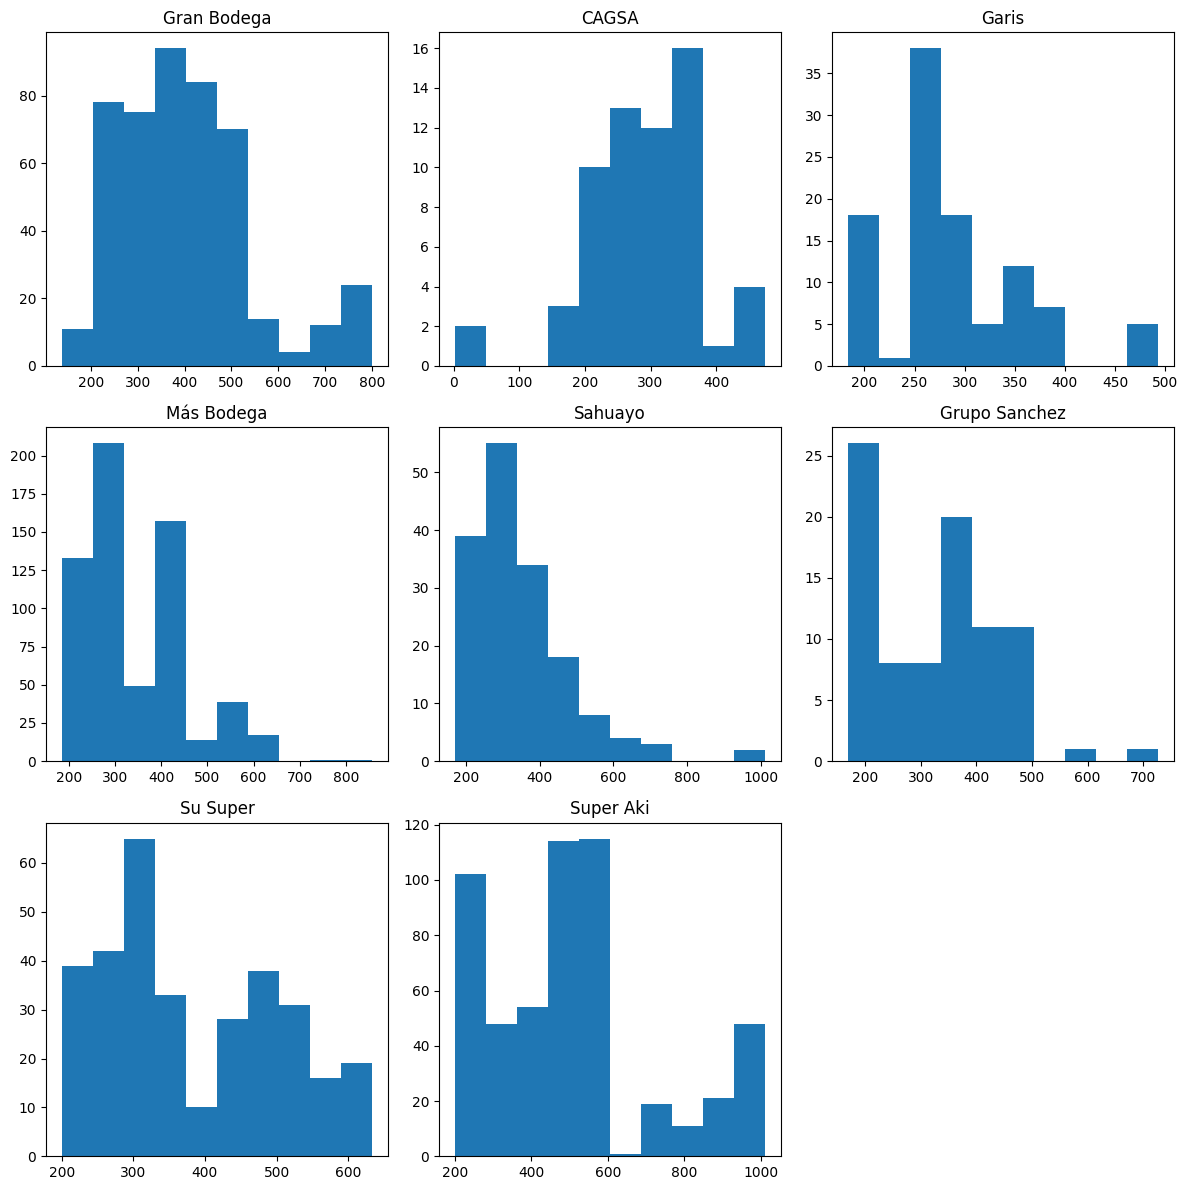

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Replace infinite values with NaN
out.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values in 'precio_unidad' column
out.dropna(subset=['precio_unidad'], inplace=True)

# Calculate the number of unique 'Cadena' values
num_cadenas = len(out['Cadena'].unique())

# Calculate the number of rows and columns for subplots
# Adjust nrows and ncols as needed to accommodate all 'Cadena' values
nrows = int(np.ceil(num_cadenas / 3))  # Example: 3 columns
ncols = 3

# Create the figure and axes with enough subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4*nrows))

# Flatten the axes array if necessary
axes = axes.flatten()

# Loop through unique 'Cadena' values and create histograms
for i, cadena in enumerate(out['Cadena'].unique()):
    # Select data for the current 'Cadena'
    cadena_data = out[out['Cadena'] == cadena]['precio_unidad']

    # Plot histogram on the corresponding axes
    axes[i].hist(cadena_data)
    axes[i].set_title(cadena)  # Set title for each subplot

# Hide any empty subplots if num_cadenas is not a multiple of nrows*ncols
for i in range(num_cadenas, nrows * ncols):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Merge

Eliminar espacios en blanco, por si fuera el caso

In [50]:
# espacios en blanco para todo los archivos a trabajar

so = so.replace(r'\s+', ' ', regex=True)

tdas = tdas.replace(r'\s+', ' ', regex=True)

ab = ab.replace(r'\s+', ' ', regex=True)

## Merge 1: Tiendas

Dado que el proveedor nos proporciona la información ya relacionada, hay que tomar el catalogo general (tiendas y productos) para buscar las inconsistencias dentro del reporte proporcionado

ELIMINAR tiendas o REMPLAZAR el registro de Tiendas

In [51]:
# Duero
so["ID_Local"] = so["ID_Local"].replace(["C004"], "C354")

# Garis
condition =(so["ID_Local"] == "E3") & (so["Cadena"] == "Garis") | \
           (so["ID_Local"] == "E5") & (so["Cadena"] == "Garis") | \
           (so["ID_Local"] == "F2") & (so["Cadena"] == "Garis") | \
           (so["ID_Local"] == "GB") & (so["Cadena"] == "Garis") | \
           (so["ID_Local"] == "BOD") & (so["Cadena"] == "Garis") | \
           (so["ID_Local"] == "CUM") & (so["Cadena"] == "Garis") | \
           (so["ID_Local"] == "LOT") & (so["Cadena"] == "Garis") | \
           (so["ID_Local"] == "MER") & (so["Cadena"] == "Garis") | \
           (so["ID_Local"] == "PAB") & (so["Cadena"] == "Garis") | \
           (so["ID_Local"] == "CUL") & (so["Cadena"] == "Garis")
#Delete rows based on the condition
so = so[~condition]

# Zorro
condition =(so["ID_Local"] == "CED") & (so["Cadena"] == "Zorro") | \
           (so["ID_Local"] == "DLS") & (so["Cadena"] == "Zorro") | \
           (so["ID_Local"] == "CPI") & (so["Cadena"] == "Zorro")
so = so[~condition]

# Sanchez
condition =(so["ID_Local"] == "VENTA EXPO") & (so["Cadena"] == "Grupo Sanchez")
so = so[~condition]


# Aki
condition =(so["ID_Local"] == "31") & (so["Cadena"] == "Super Aki")
so = so[~condition]

so.loc[(so["ID_Local"] == "127") & (so["Cadena"] == "Super Aki"), "ID_Local"] = "127"

# Gran Bodega
so.loc[(so["ID_Local"] == "83") & (so["Cadena"] == "Gran Bodega"), "ID_Local"] = "83 IZUCAR"


# PCZ
#eliminar los siguientes puntos de venta
condition =(so["ID_Local"] == 603) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 251) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 902) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 602) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 500) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 284) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 862) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 2) & (so["Cadena"] == "PCZ")   | \
           (so["ID_Local"] == 922) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 792) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 942) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 842) & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == "200-Id") & (so["Cadena"] == "PCZ") | \
           (so["ID_Local"] == 822) & (so["Cadena"] == "PCZ")
# Delete rows based on the condition
so = so[~condition]

# sustitucion de tienda
so.loc[(so["ID_Local"] == "827") & (so["Cadena"] == "PCZ"), "ID_Local"] = "487"
so.loc[(so["ID_Local"] == "832") & (so["Cadena"] == "PCZ"), "ID_Local"] = "831"

# Sahuayo
so.loc[(so["ID_Local"] == "12") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "11"
so.loc[(so["ID_Local"] == "12603") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "49"
so.loc[(so["ID_Local"] == "13") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "9"
so.loc[(so["ID_Local"] == "16") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "102"
so.loc[(so["ID_Local"] == "17") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "63"
so.loc[(so["ID_Local"] == "21") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "18"
so.loc[(so["ID_Local"] == "22") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "19"
so.loc[(so["ID_Local"] == "23") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "84"
so.loc[(so["ID_Local"] == "25") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "51"
so.loc[(so["ID_Local"] == "27") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "24"
so.loc[(so["ID_Local"] == "31") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "15"
so.loc[(so["ID_Local"] == "32") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "69"
so.loc[(so["ID_Local"] == "34") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "33"
so.loc[(so["ID_Local"] == "38") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "36"
so.loc[(so["ID_Local"] == "41") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "42"
so.loc[(so["ID_Local"] == "5") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "26"
so.loc[(so["ID_Local"] == "7") & (so["Cadena"] == "Sahuayo"), "ID_Local"] = "58"


#CAGSA
condition =(so["ID_Local"] == 285827) & (so["Cadena"] == "CAGSA")
so = so[~condition]




Dado que existen incosistencias en el Dataset por el ID_Local que relacionan en Dbyte, es necesario realizar un remplazo de estos por el valor original

In [55]:
# catalogo de tiendas relacionadas
tdas_dbyte=pd.read_excel("/content/drive/MyDrive/Sell Out/Dbyte_cubos/RelTdas_Dbyte.xlsx")
tdas_dbyte = tdas_dbyte.replace(r'\s+', ' ', regex=True)

tdas_dbyte.tail(5)

,Cadena,ID_local,nombre_local,ID_Original
1210,PCZ,3-E86,NICOLAS ROMERO 2,E22
1211,PCZ,31-Id,FINANZAS,NaN
1212,PCZ,862,Tuxtla Norte,861
1213,PCZ,937,Tienda Nueva CMZT 937 - SUC. HUIMANGUILLO 8,937
1214,Casa Vargas,287858,SANTA LUCIA,34


In [56]:
# renombrar columnas
tdas_dbyte= tdas_dbyte.rename(columns={'Cadena': "Holding"})
tdas_dbyte= tdas_dbyte.rename(columns={'ID_Original': "Código Punto de Venta Cadena"})
tdas_dbyte= tdas_dbyte.rename(columns={'nombre_local': "Nombre de Tienda"})

# Key Tda
tdas_dbyte['key_tda'] =tdas_dbyte['Holding'].astype(str) + tdas_dbyte['ID_local'].astype(str)

# seleccionar y reordenar columnas
tdas_dbyte=tdas_dbyte.iloc[:,[3,4]]
tdas_dbyte = tdas_dbyte.iloc[:, [1,0]]

tdas_dbyte.head(5)

,key_tda,Código Punto de Venta Cadena
0,Gran Bodega1,1 RIVERA
1,Gran Bodega10,10 XILOT
2,Gran Bodega12,12 MOM
3,Gran Bodega13,13 CAPU
4,Gran Bodega14,14 AMA


Tengo que hacer un loop para buscar el **"KEY_TDA" en SO**, y sobre este hacer el cambio en la columna de **ID_Local** con el **Código Punto de Venta Cadena** proveniente del catalogo de **tiendas de Dbyte**

Mapping de tiendas Dbyte hacia tiendas Sell Outs

In [57]:
# changue data type
so['ID_Local'] = so['ID_Local'].astype(str)
tdas_dbyte['key_tda'] = tdas_dbyte['key_tda'].astype(str)

# Create a dictionary mapping 'key_tda' (tdas_dbyte) to 'Código Punto de Venta Cadena' (so)
replacement_dict = dict(zip(tdas_dbyte['key_tda'], tdas_dbyte['Código Punto de Venta Cadena']))

# Use the dictionary to replace values in 'so'
so['ID_Local'] = so['keytda'].map(replacement_dict).fillna(so['ID_Local'])

Merge con catalogo de Tiendas

In [58]:
# reformar de nuevo la columna key_tda (referenciar a catalogos de tienda) sobre la ya realizada
so['keytda'] =so['Cadena'].astype(str) + so['ID_Local'].astype(str)

In [59]:
# tiendas
so = so.merge(tdas, left_on="keytda", right_on="key_tda", how="left")

In [60]:
# eliminar tdas con descripcion eliminar
so = so[so['ID_Local'] != 'eliminar']

In [61]:
so.head(5)

,fecha,Cadena,ID_Local,Nombre_Local,sku_softys,Cjas_Blts,importe_s/iva,Inv_cjas,importe_c/iva,keytda,key_tda
0,2025-04-27,Gran Bodega,10 XILOT,LA GRAN BODEGA XILOTZINGO,AB10332963,0.0,0.0,1.0,0.0,Gran Bodega10 XILOT,Gran Bodega10 XILOT
1,2025-04-27,Gran Bodega,47 GEO,LA GRAN BODEGA GEO SAN LORENZO,AB19101675,0.0,0.0,1.0,0.0,Gran Bodega47 GEO,Gran Bodega47 GEO
2,2025-04-27,Gran Bodega,1 RIVERA,PROVEEDORA DE ABARROTES RIVERA,AB19101675,0.0,0.0,1.0,0.0,Gran Bodega1 RIVERA,Gran Bodega1 RIVERA
3,2025-04-27,Gran Bodega,3 RIK 2,ABARROTES RIKOZA SUC. 2,AB11332642,0.0,0.0,1.0,0.0,Gran Bodega3 RIK 2,Gran Bodega3 RIK 2
4,2025-04-27,Gran Bodega,81 PEROTE,LA GRAN BODEGA PEROTE,AB14101675,0.0,0.0,1.0,0.0,Gran Bodega81 PEROTE,Gran Bodega81 PEROTE


Exportar las relaciones

In [62]:
nas= so[so.isna().any(axis=1)]  #revisar registros con datos faltantes
nas.to_excel('nas.xlsx',sheet_name = 'Sheet1',index=False)

nas.tail()

#so.dropna(inplace=True) #eliminar registros con datos faltantes

,fecha,Cadena,ID_Local,Nombre_Local,sku_softys,Cjas_Blts,importe_s/iva,Inv_cjas,importe_c/iva,keytda,key_tda


## Merge 2 Productos EAN a Codigo Material

Cambiar el "Codigo Softys" proporcionado por Dbyte, con su respecto "Codigo de Material" en el catalago de Prod_Holding. Se esta tomando la columna EAN como criterio pivote para realizar los cambios. **En caso de que no hayan compartido el AB´s**

In [64]:
so['sku_softys'] = so['sku_softys'].astype(str)
prod_holding['EAN'] = prod_holding['EAN'].astype(str)

# Create a dictionary mapping prod_holding['EAN'] to so['sku_softys']
replacement_dict = dict(zip(prod_holding['EAN'], prod_holding['CODIGO']))

# Use the dictionary to replace values in 'so'
so['sku_softys'] = so['sku_softys'].map(replacement_dict).fillna(so['sku_softys'])

*No es necesario hacer un merge con el catalago de productos de BI porque ya se hizo la relación de codigos con el catalogo de Prod_Holding (donde se sustituye el EAN por el Codigo Actual desde el pre-procesamiento en Dbyte)* **SOLO APLICA PARA PERSONAL CARE**

In [ ]:
# solo aplica para el caso de PC

#so= so.merge(prod_holding, left_on="sku_softys", right_on="CODIGO", how="left")

In [65]:
print(so.isnull().sum())

fecha            0
Cadena           0
ID_Local         0
Nombre_Local     0
sku_softys       0
Cjas_Blts        0
importe_s/iva    0
Inv_cjas         0
importe_c/iva    0
keytda           0
key_tda          0
dtype: int64


In [66]:
nas= so[so.isna().any(axis=1)]  #revisar registros con datos faltantes
nas.to_excel('nas.xlsx',sheet_name = 'Sheet1',index=False)

nas.tail()
#so.dropna(inplace=True) #eliminar registros con datos faltantes

,fecha,Cadena,ID_Local,Nombre_Local,sku_softys,Cjas_Blts,importe_s/iva,Inv_cjas,importe_c/iva,keytda,key_tda


# Layout BI

Renombras columnas en función del layout original

In [67]:
so = so.iloc[:,[0,1,2,4,5,6,7,8]]
so.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3500 entries, 0 to 3500
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   fecha          3500 non-null   datetime64[ns]
 1   Cadena         3500 non-null   object        
 2   ID_Local       3500 non-null   object        
 3   sku_softys     3500 non-null   object        
 4   Cjas_Blts      3500 non-null   float64       
 5   importe_s/iva  3500 non-null   float64       
 6   Inv_cjas       3500 non-null   float64       
 7   importe_c/iva  3500 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 246.1+ KB


In [68]:
so= so.rename(columns={'Cadena': "Holding"})  #renombrar una columna

so= so.rename(columns={'ID_Local': "ID Cliente"})  #renombrar una columna

so= so.rename(columns={'sku_softys': "Cve Material"})  #renombrar una columna

so= so.rename(columns={'importe_s/iva': "$"})  #renombrar una columna
so= so.rename(columns={'importe_c/iva': "$_imp"})  #renombrar una columna

so= so.rename(columns={'Inv_cjas': "Inv Cjas"})  #renombrar una columna

exportar el conjunto de datos

In [69]:
pivot_table=pd.pivot_table(data=so,
                           index=[ "fecha","Holding", "ID Cliente", "Cve Material"],
                           values=["Cjas_Blts", "$", "Inv Cjas", "$_imp"],
                           aggfunc=np.sum,
                           fill_value=0,)    #tabla dinamica

# Assuming you want the current column order
column_order = ["fecha","Holding", "ID Cliente", "Cve Material","Cjas_Blts", "$", "Inv Cjas", "$_imp"]

pivot_table.reset_index().to_excel('sell out.xlsx',sheet_name = 'Sheet1',index=False, columns= column_order)

pivot_table.head(5)

/tmp/ipython-input-2157975748.py:1: FutureWarning: The provided callable <function sum at 0x79cff0717920> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivot_table=pd.pivot_table(data=so,


$    $_imp  Cjas_Blts  \
fecha      Holding ID Cliente Cve Material                                 
2025-04-27 CAGSA   1          AB12332659     1280.17   1485.0        6.0   
                              AB18335636     2346.55   2722.0        8.0   
                              AB40006741     2504.31   2905.0       10.0   
                   2          AB12332659    13954.31  16187.0       65.0   
                              AB13335678     3344.83   3880.0       20.0   

                                            Inv Cjas  
fecha      Holding ID Cliente Cve Material            
2025-04-27 CAGSA   1          AB12332659        42.0  
                              AB18335636         9.0  
                              AB40006741        47.0  
                   2          AB12332659        47.0  
                              AB13335678       191.0